# MNIST Dataset

MNIST is a dataset of **70,000 handwritten digit images** from 0 to 9.

Each image is **28 × 28 pixels**, resulting in **784 features** after flattening the image into a one-dimensional array.

* `X` → pixel values of the images
* `y` → corresponding digit labels
* Each pixel is a grayscale intensity value between **0 and 255**

The `sklearn.datasets` package provides three main types of functions:

* `fetch_*` → download real-world datasets.
* `load_*` → load small datasets bundled with Scikit-Learn.
* `make_*` → generate synthetic datasets for testing and experimentation.

Datasets may be returned as NumPy arrays, `(X, y)` tuples, or `Bunch` objects.

`fetch_openml()` returns Pandas objects by default, but `as_frame=False` can be used to get NumPy arrays, which is more convenient for datasets such as MNIST.



In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

X, y = mnist.data, mnist.target

Some Scikit-Learn datasets are returned as a `Bunch` object, which behaves like a dictionary and also allows attribute-style access.

Common entries include:

* `DESCR` → description of the dataset
* `data` → input features, usually a 2D NumPy array
* `target` → target labels, usually a 1D NumPy array


In [2]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [3]:
print(X.shape, X.dtype, sep=" | ")
print(y.shape, y.dtype, sep=" | ")


(70000, 784) | int64
(70000,) | object


In [4]:
y[0]

'5'

In [5]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

The output is not suitable for visualizing as an image, so let's reshape it back to its original `28 × 28` format.

# Reshaping MNIST Images

Each MNIST image is stored as a 1D array of 784 pixel values.

To visualize an image, we reshape it back to its original `28 × 28` format:

`784 → 28 × 28`

`reshape()` changes the shape of the array without changing its values.


In [6]:
X[10].reshape(28, 28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

# Visualizing MNIST Images

A helper function can be used to reshape a flattened MNIST image back to `28 × 28` and display it with Matplotlib.

This makes it easy to visualize different samples by passing their flattened pixel data to the function.


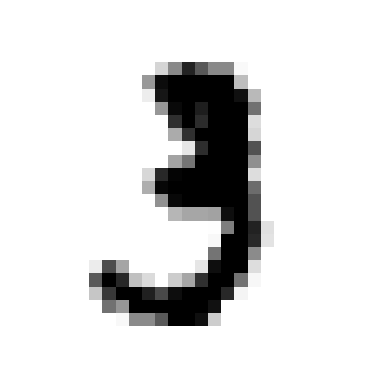

In [7]:
import matplotlib.pyplot as plt


def show_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


some_digit = X[10]
show_image(some_digit)

In [8]:
y[10]

'3'

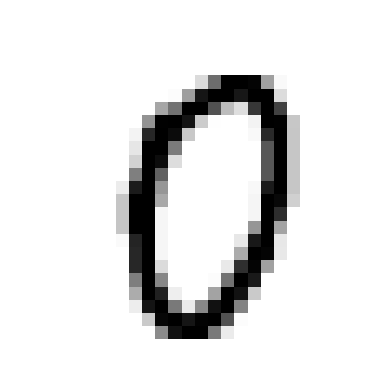

In [9]:
show_image(X[1000])

In [10]:
y[1000]

'0'

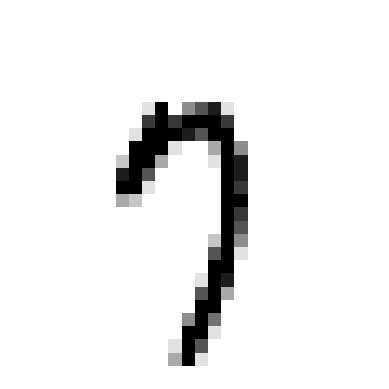

In [11]:
show_image(X[50021])

In [12]:
y[50021]

'7'

# MNIST Train/Test Split

The MNIST dataset already provides a standard split:

* **60,000 images** → training set
* **10,000 images** → test set

The test set should be kept separate and untouched until the final evaluation to avoid **data leakage** and obtain a reliable estimate of the model's generalization performance.


In [13]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
some_digit = X_train[10]

# Shuffling the Training Set

The MNIST training set is already shuffled.

Shuffling helps ensure that:

* Cross-validation folds contain a representative mix of classes.
* Order-sensitive learning algorithms do not receive many similar samples consecutively.

Shuffling is especially important for algorithms that process training instances sequentially, such as **Stochastic Gradient Descent (SGD)**.


# Training a Binary Classifier with SGD

For this classification task, we train an `SGDClassifier` to distinguish between the digit **3** and all other digits.

* **Classifier:** A model that assigns an input to a class.
* **Binary classification:** A classification problem with two classes: `3` and `not 3`.
* **SGD:** A method used to train the classifier.
* **`fit()`:** Trains the classifier using the training data and their corresponding target labels.

In [14]:
from sklearn.linear_model import SGDClassifier

y_train_3 = (y_train == "3") # True for all 3s, False for all other digits
y_test_3 = (y_test == "3")

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

After training, the classifier can make predictions for new images:

`predict()` expects a collection of samples. Since `some_digit` represents one image with **784 features**, wrapping it in a list changes its shape from `(784,)` to 

`(1, 784)`, meaning **1 sample with 784 features**.


In [15]:
sgd_clf.predict([some_digit])

array([ True])

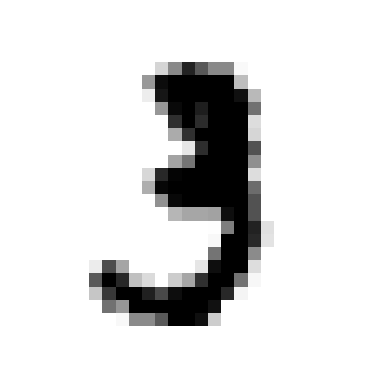

In [16]:
show_image(some_digit)

In [17]:
sgd_clf.predict([X[122]])

array([False])

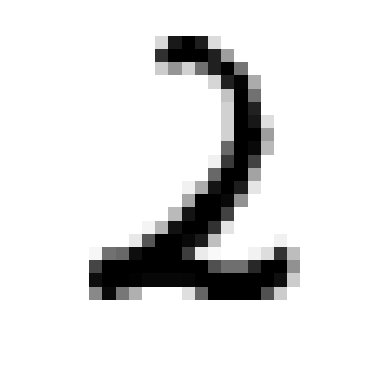

In [18]:
show_image(X[122])

In [19]:
X[0].shape

(784,)

# Evaluating a Classifier with Cross-Validation

`cross_val_score()` can be used to evaluate a classifier using k-fold cross-validation.

With `cv=3`, the training set is divided into three folds. The model is trained and evaluated three times, using a different fold for evaluation each time.

The `scoring="accuracy"` argument measures the percentage of correct predictions.

In [20]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.9496 , 0.9624 , 0.96275])

The classifier achieves about **95–96% accuracy across the three cross-validation folds**.

# DummyClassifier
`DummyClassifier` is used as a simple baseline model. In this example, it predicts the majority class (`not 3`) for every image without learning any meaningful pattern from the pixel features.

The `any()` function checks whether there is at least one `True` value among the predictions. Therefore, if the result is `False`, it means that `DummyClassifier` predicted `not 3` for every image in the training set and did not identify a single image as `3`.

This demonstrates why a high accuracy score can be misleading when the classes are imbalanced.


In [21]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_3)
any(dummy_clf.predict(X_train))

False

In [22]:
cross_val_score(dummy_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.89785, 0.8978 , 0.8978 ])

In [23]:
y_train_3.sum() / y_train_3.size

np.float64(0.10218333333333333)

Cross-validation gives about **90% accuracy** because approximately **90%** of the training images belong to the `not 3` class.

The class distribution confirms that this high accuracy comes from the imbalance between the two classes, not from learning useful patterns from the images.

# Generating Out-of-Sample Predictions

Before creating a **Confusion Matrix**, we need predictions that can be fairly compared with the actual target labels.

The `cross_val_predict()` function uses **k-fold cross-validation** to generate **out-of-sample predictions** for every training instance.

With `cv=3`, the training set is divided into three folds. The classifier is trained three times:

1. Train on Folds 2 and 3 → predict Fold 1
2. Train on Folds 1 and 3 → predict Fold 2
3. Train on Folds 1 and 2 → predict Fold 3

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_prediction = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)
y_train_prediction

array([False, False, False, ..., False, False, False], shape=(60000,))

Each instance is therefore predicted by a model that **did not see that instance during training**.

The predictions from all three folds are combined into a single array. The order of these predictions corresponds to the order of `X_train`.

These **out-of-sample predictions** can then be compared with the actual labels to construct a **Confusion Matrix**

In [25]:
y_train_prediction[10]

np.True_

In [26]:
y_train[10]

'3'

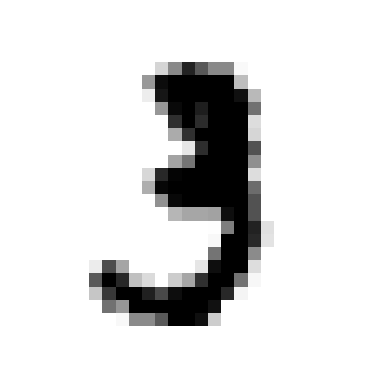

In [27]:
show_image(some_digit)

# Confusion Matrix

A **Confusion Matrix** shows how a classifier's predictions compare with the actual target labels. It counts how many instances of each actual class were classified as each predicted class.

For binary classification, the matrix contains four outcomes:

| Actual   | Predicted | Result                  |
| -------- | --------- | ----------------------- |
| Positive | Positive  | **True Positive (TP)**  |
| Negative | Positive  | **False Positive (FP)** |
| Positive | Negative  | **False Negative (FN)** |
| Negative | Negative  | **True Negative (TN)**  |

The rows represent the **actual classes**, while the columns represent the **predicted classes**.

```text
                  Predicted
                Negative   Positive
Actual Negative    TN         FP
       Positive    FN         TP
```

* **TP:** The classifier correctly predicts a positive instance.
* **TN:** The classifier correctly predicts a negative instance.
* **FP:** The classifier predicts positive, but the instance is actually negative.
* **FN:** The classifier predicts negative, but the instance is actually positive.

The main diagonal contains the **correct predictions** (`TN` and `TP`), while the off-diagonal cells contain the **classification errors** (`FP` and `FN`).

A Confusion Matrix can be computed using the actual labels and the out-of-sample predictions generated by `cross_val_predict()`

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_3, y_train_prediction)
cm

array([[53477,   392],
       [ 2113,  4018]])

For **multiclass classification**, the matrix becomes larger. If there are `n` classes, the Confusion Matrix has a size of:

$$
n \times n
$$

Each row represents an actual class, and each column represents a predicted class.

In [29]:
y_train_perfect_prediction = y_train_3  # pretend we reached perfection
confusion_matrix(y_train_3, y_train_perfect_prediction)

array([[53869,     0],
       [    0,  6131]])

# Precision and Recall

Both **Precision** and **Recall** are classification metrics derived from the **Confusion Matrix**. They focus on the positive class but measure different aspects of the classifier's performance.

## Precision

**Precision** measures how reliable the classifier's positive predictions are.

In other words:

> Of all instances predicted as positive, how many were actually positive?

The formula is:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Where:

* **TP (True Positive):** The instance is actually positive and the classifier predicts positive.
* **FP (False Positive):** The instance is actually negative, but the classifier predicts positive.

Therefore, Precision only considers instances that the classifier **predicted as positive**.

For example, suppose the classifier predicts 100 images as `3`, but only 80 of them are actually `3`:

$$
\text{Precision} = \frac{80}{80 + 20} = 80\%
$$

A higher Precision means that positive predictions are more trustworthy.

## Why Precision Alone Is Not Enough

Consider a classifier that is extremely cautious and only makes a positive prediction when it is very confident.

In the extreme case, suppose it predicts **positive for only one instance**, and that prediction is correct:

$$
\text{Precision} = \frac{1}{1} = 100\%
$$

Although the classifier has perfect Precision, it may still be very poor because it ignores almost all other positive instances.

For example, if there are 100 actual positive instances but the classifier detects only one:

$$
\text{Recall} = \frac{1}{100} = 1\%
$$

Therefore, a classifier can have **100% Precision but only 1% Recall**.

## Recall

**Recall**, also called **Sensitivity** or **True Positive Rate (TPR)**, measures the proportion of actual positive instances that the classifier correctly detects.

In other words:

> Of all actual positive instances, how many did the classifier correctly identify?

The formula is:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Where:

* **TP (True Positive):** The instance is actually positive and the classifier predicts positive.
* **FN (False Negative):** The instance is actually positive, but the classifier predicts negative.

Therefore, Recall considers **all actual positive instances**, whether the classifier detected them or missed them.

For example, if there are 100 actual positive instances and the classifier correctly detects 80:

$$
\text{Recall} = \frac{80}{80 + 20} = 80\%
$$

## Precision vs. Recall

The two metrics answer different questions:

* **Precision:** When the classifier predicts positive, how often is it correct?
* **Recall:** Of all actual positive instances, how many did the classifier detect?

$$
\boxed{\text{Precision} = \frac{TP}{TP + FP}}
$$

$$
\boxed{\text{Recall} = \frac{TP}{TP + FN}}
$$

A classifier that tries to increase Precision often becomes more cautious about making positive predictions, which can reduce Recall. Conversely, detecting more positive instances can increase Recall while potentially reducing Precision.

Therefore, **Precision and Recall are typically considered together** rather than relying on either metric alone.


In [30]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_3, y_train_prediction))
print(recall_score(y_train_3, y_train_prediction))

0.9111111111111111
0.655358016636764


# F1 Score

Sometimes it is useful to combine **Precision** and **Recall** into a single metric, especially when comparing different classifiers. This metric is called the **F1 Score**.

The F1 Score is the **harmonic mean** of Precision and Recall:

$$
F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Unlike the arithmetic mean, the harmonic mean gives more weight to lower values. Therefore, the F1 Score will be high only when **both Precision and Recall are relatively high**.

For example:

$$
Precision = 90\%, \quad Recall = 10\%
$$

$$
F_1 = 2 \times \frac{0.9 \times 0.1}{0.9 + 0.1} = 18\%
$$

This shows that a classifier cannot obtain a high F1 Score by having only one strong metric.

### F1 Score Is Not Always the Best Metric

F1 favors classifiers with a balance between Precision and Recall. However, in some applications, one of these metrics may be more important than the other.

* **High Precision:** Useful when False Positives are particularly costly. For example, when detecting videos that are safe for children, it may be preferable to reject some safe videos rather than allow unsafe videos.
* **High Recall:** Useful when False Negatives are particularly costly. For example, in medical diagnosis or detecting shoplifters, missing a real positive case can be more problematic than generating some false alerts.

Therefore, **F1 Score should not automatically be considered the best metric**. The appropriate metric depends on the consequences of False Positives and False Negatives in the specific application.


In [31]:
from sklearn.metrics import f1_score

f1_score(y_train_3, y_train_prediction)

0.7623565126648325

# Precision/Recall Trade-Off

The `SGDClassifier` computes a **score** for each instance and compares it with a **threshold** to make a classification decision:

* `score > threshold` → **Positive**
* `score ≤ threshold` → **Negative**

The `threshold` can be viewed as the **strictness of the classifier** when deciding whether an instance belongs to the positive class.

* **Increasing the threshold:** The classifier becomes more strict → **Precision increases**, while **Recall decreases**.
* **Decreasing the threshold:** The classifier becomes less strict → **Recall increases**, while **Precision decreases**.

Therefore, changing the threshold creates a **trade-off between Precision and Recall**.


# Decision Function

Instead of using `predict()`, the `decision_function()` method returns a **score** for each instance.

We can then choose the classification threshold ourselves:

In [32]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([1378.05599034])

If the score is greater than the threshold, the prediction is **Positive**; otherwise, it is **Negative**.

This allows us to change the threshold and control the trade-off between **Precision** and **Recall**.

In [33]:
threshold = 0
y_scores >= threshold

array([ True])

In [34]:
threshold = 3000
y_scores > threshold

array([False])

# Generating Decision Scores

The `cross_val_predict()` function can generate **out-of-sample decision scores** instead of final predictions by using `method="decision_function"`.

With `cv=3`, each training instance receives a score from a model that **did not see that instance during training**.

These scores can then be compared with different **thresholds** to control the trade-off between Precision and Recall.


In [35]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3, method="decision_function")
y_scores

array([ -8938.67345168, -17073.83659907,  -2250.42625883, ...,
       -15330.33317379, -25099.35767753, -36457.78038114], shape=(60000,))

# Calculating Precision and Recall for Different Thresholds

The `precision_recall_curve()` function calculates **Precision** and **Recall** for different decision thresholds using the actual labels and the decision scores.

It returns three arrays:

* `precisions`: Precision values for the different thresholds.
* `recalls`: Recall values for the different thresholds.
* `thresholds`: The decision thresholds used to calculate these values.

These results can later be used to visualize the **Precision/Recall trade-off** and understand how changing the threshold affects the classifier.


In [36]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_3, y_scores)

# Plotting the Precision/Recall Trade-Off

The calculated Precision and Recall values can be plotted against their corresponding decision thresholds.

The plot shows how **Precision** and **Recall** change as the classification threshold changes. A vertical line is also added to indicate the currently selected threshold.

* The **Precision** curve generally increases as the threshold increases.
* The **Recall** curve generally decreases as the threshold increases.
* The vertical line shows the current decision threshold.

This visualization makes the **Precision/Recall trade-off** easier to understand and helps us choose an appropriate threshold.


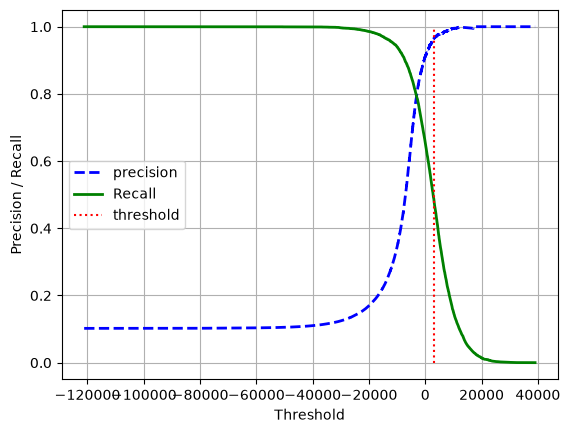

In [37]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], "b--", label="precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "red", "dotted", label="threshold")
plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.grid()
plt.legend()
plt.show()

The `precisions` and `recalls` arrays contain **one more value than the `thresholds` array**.

The last values of `precisions` and `recalls` do not correspond to an actual decision threshold. They are added as an endpoint to complete the Precision/Recall curve.

Therefore, we use `[:-1]` when plotting so that the number of Precision and Recall values matches the number of thresholds.


When the threshold increases:

* **Recall** can only decrease or stay the same.
* **Precision** generally increases, but it can sometimes decrease.

This is why the Precision curve can be **bumpier**, while the Recall curve is usually smoother.


At this threshold value, precision is near 95% and recall is around 50%. Another way
to select a good precision/recall trade-off is to plot precision directly against recall:

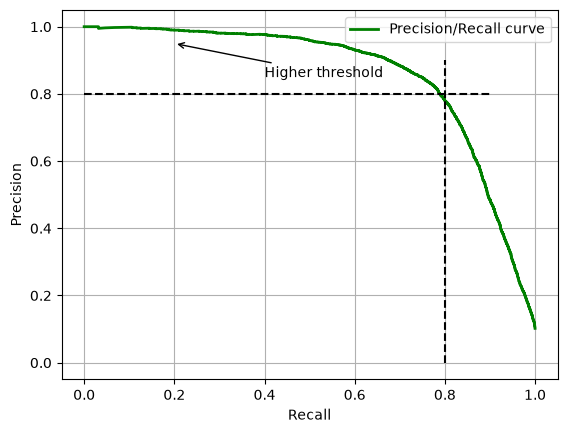

In [38]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve", c="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.vlines(
    0.8,
    0,
    0.9,
    "k",
    linestyles="dashed"
)

plt.hlines(
    0.8,
    0,
    0.9,
    "k",
    linestyles="dashed"
)

plt.annotate(
    "Higher threshold",
    xy=(0.2, 0.95),
    xytext=(0.4, 0.85),
    arrowprops=dict(arrowstyle="->")
)

plt.grid()
plt.legend()
plt.show()

# Selecting a Threshold for a Target Precision

Instead of choosing a threshold visually from the Precision/Recall plot, we can find it precisely using the calculated `precisions` and `thresholds` arrays.

Suppose we want the classifier to achieve at least **90% Precision**.

First, we identify which Precision values satisfy this condition:

`precisions >= 0.90`

This produces a Boolean array containing `True` for Precision values of at least 90% and `False` otherwise.

The `argmax()` method can then find the **first `True` value** because Boolean values are treated numerically:

* `False` → `0`
* `True` → `1`

Since the `thresholds` array is ordered from lower to higher values, the first `True` corresponds to the **lowest threshold that achieves at least 90% Precision**.

This allows us to select the required threshold precisely instead of estimating it from the plot.


In [39]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(-411.44326592496236)

In [40]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
y_train_pred_90

array([False, False, False, ..., False, False, False], shape=(60000,))

In [41]:
precision_score(y_train_3, y_train_pred_90)

0.9000870700914236

In [42]:
recall_at_90_precision = recall_score(y_train_3, y_train_pred_90)
recall_at_90_precision

0.6744413635622247

# ROC Curve

The **ROC (Receiver Operating Characteristic) curve** is another common tool for evaluating binary classifiers.

It plots:

* **True Positive Rate (TPR)** on the y-axis, which is the same as **Recall / Sensitivity**.
* **False Positive Rate (FPR)** on the x-axis.

The **False Positive Rate** measures the proportion of actual negative instances that are incorrectly classified as positive:

$$
FPR = \frac{FP}{FP + TN}
$$

The **True Negative Rate (TNR)** measures the proportion of actual negative instances that are correctly classified as negative:

$$
TNR = \frac{TN}{TN + FP}
$$

TNR is also called **Specificity**, so:

$$
FPR = 1 - TNR = 1 - Specificity
$$

Therefore, the ROC curve can also be described as:

$$
\text{Sensitivity (Recall)} \quad \text{vs.} \quad 1 - \text{Specificity}
$$

The `roc_curve()` function can be used to calculate the **TPR and FPR for different decision thresholds**, allowing us to visualize how changing the threshold affects the classifier.

The selected threshold for **90% precision** is matched to the corresponding point on the ROC curve by finding its index in the `thresholds` array.

Because the thresholds are listed in decreasing order, `<=` is used to find the first threshold that is at or below the selected threshold. This index is then used to retrieve the corresponding **TPR** and **FPR** values.



In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_3, y_scores)
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# Plotting the ROC Curve
The ROC curve plots **TPR (Recall)** against **FPR** for different decision thresholds.

The dotted diagonal represents a **random classifier**, while the marked point shows the ROC performance at the threshold selected for **90% precision**. The curved annotation indicates the effect of increasing the classification threshold.


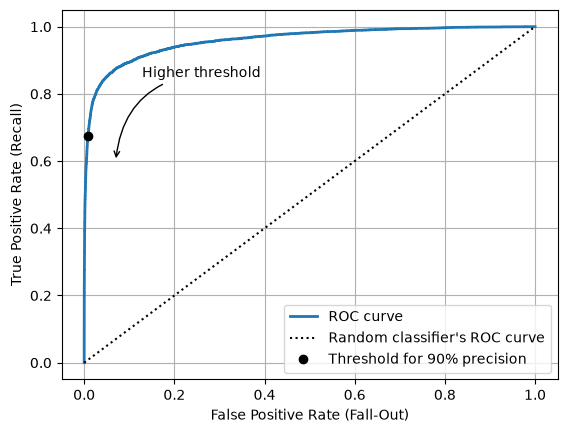

In [44]:
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("True Positive Rate (Recall)")
plt.grid()
plt.legend()

plt.annotate(
    "Higher threshold",
    xy=(0.07, 0.6),
    xytext=(0.26, 0.85),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.4"
    ),
    ha="center"
)

plt.show()

# ROC AUC

The **ROC AUC (Area Under the ROC Curve)** summarizes the classifier's overall ability to distinguish between positive and negative classes across different decision thresholds.

* **AUC = 1.0** → Perfect classifier
* **AUC = 0.5** → Random classifier

A higher ROC AUC generally indicates better separation between the positive and negative classes.

Scikit-Learn provides `roc_auc_score()` to calculate the ROC AUC:

In [61]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_3, y_scores)

0.9599243001892759

ROC AUC should not be interpreted as **accuracy**. For example, an AUC of `0.96` does not mean that the classifier has 96% accuracy at a specific threshold.

# ROC Curve vs. Precision/Recall Curve

ROC and Precision/Recall (PR) curves both show how changing the **decision threshold** affects a binary classifier, but they emphasize different aspects of performance.

## When to Prefer the PR Curve

As a rule of thumb, prefer the **PR curve** when:

* The **positive class is rare**.
* **False positives** are more important or costly than false negatives.

Otherwise, the **ROC curve** can be a suitable choice.

## Why Class Imbalance Matters

Suppose:

* 90% of the instances are `not 3`.
* Only 10% of the instances are `3`.

The ROC curve uses the **False Positive Rate (FPR)**:

$$
FPR = \frac{FP}{FP + TN}
$$

Because there are many negative instances, there can be a considerable number of **False Positives** while the FPR remains relatively small due to the large number of **True Negatives**.

As a result, the **ROC curve and ROC AUC may look very good**, even when the classifier is not particularly good at detecting the rare positive class.

The **PR curve**, on the other hand, focuses directly on **Precision and Recall**, making it more informative about the classifier's performance on the positive class when that class is rare.

> **Rule of thumb:** Rare positive class → PR curve is often more informative; otherwise, ROC curve is often suitable.

This is not an absolute rule. The choice should also depend on the specific problem and the relative cost of **False Positives** and **False Negatives**.


# Random Forest Classifier

The `RandomForestClassifier` is another classification model that we can compare with the `SGDClassifier`.

Unlike `SGDClassifier`, it does not provide a `decision_function()` method. Instead, `predict_proba()` returns the estimated probability of each class for every instance.

We use `cross_val_predict()` with `method="predict_proba"` to generate **out-of-sample class probabilities** for every training instance using 3-fold cross-validation.

For binary classification, each row contains the estimated probability of the negative and positive classes:

* Column `0` → probability of the negative class (`not 3`)
* Column `1` → probability of the positive class (`3`)

These probabilities can later be used as scores to calculate the **Precision/Recall curve** and compare the Random Forest with the `SGDClassifier`.


In [62]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_3, cv=3,
 method="predict_proba")
y_probas_forest[:10]

array([[0.62, 0.38],
       [1.  , 0.  ]])

The second column contains the **estimated probabilities** for the positive class, so let’s
pass them to the `precision_recall_curve()` function:

In [66]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_3, y_scores_forest)

# Comparing Precision/Recall Curves

The Precision/Recall curves allow us to compare the performance of the **Random Forest** and **SGD** classifiers across different decision thresholds.

A curve that stays higher generally indicates a better trade-off between **Precision and Recall**.


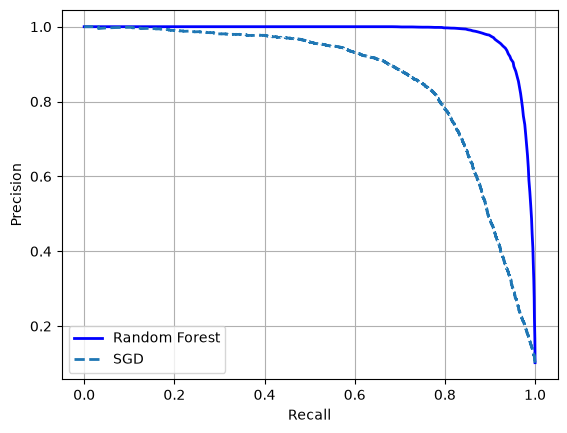

In [67]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
 label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend()
plt.show()

Comparing **PR curves**: the random forest classifier is **superior** to the SGD
classifier because its PR curve is much closer to the top-right corner, and it has a greater
**AUC**

# Random Forest Evaluation

The positive-class probabilities are converted into predictions using a **50% threshold**, and the **F1 score** is calculated.

In the following cells, **Precision, Recall, and ROC AUC** are also evaluated to complete the comparison of the classifier's performance.


In [68]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # positive proba ≥ 50%
f1_score(y_train_3, y_train_pred_forest)

0.9105216622458002

In [70]:
roc_auc_score(y_train_3, y_scores_forest)

0.995864544068936

In [74]:
precision_score(y_train_3, y_train_pred_forest)

0.9942073759413014

In [72]:
recall_score(y_train_3, y_train_pred_forest)

0.8398303702495514

**Precision, Recall, and F1** use binary predictions produced after applying a specific threshold.

**ROC AUC** uses the raw scores or probabilities because it evaluates the classifier across **different thresholds**.


# Multiclass Classification

**Multiclass classification** is a classification problem involving more than two classes. For example, the MNIST dataset contains 10 classes, representing the digits `0` through `9`.

Some Scikit-Learn classifiers can handle multiclass classification **natively**, such as `LogisticRegression`, `RandomForestClassifier`, and `GaussianNB`.

Other classifiers, such as `SGDClassifier` and `SVC`, are binary classifiers. Scikit-Learn automatically applies a suitable multiclass strategy depending on the algorithm.

## One-versus-Rest (OvR)

In the **One-versus-Rest (OvR)** strategy, one binary classifier is trained for each class.

For MNIST, this means training 10 classifiers:

* `0` vs. all other digits
* `1` vs. all other digits
* ...
* `9` vs. all other digits

When classifying a new image, all classifiers produce a decision score. The class whose classifier produces the highest score is selected as the prediction.

For `N` classes, OvR requires **N binary classifiers**.

## One-versus-One (OvO)

In the **One-versus-One (OvO)** strategy, a binary classifier is trained for every pair of classes.

For MNIST, classifiers are trained for pairs such as:

* `0` vs. `1`
* `0` vs. `2`
* `1` vs. `2`
* ...
* `8` vs. `9`

For `N` classes, OvO requires:

$$
\frac{N(N-1)}{2}
$$

binary classifiers.

Therefore, MNIST with 10 classes requires:

$$
\frac{10 \times 9}{2} = 45
$$

binary classifiers.

When classifying a new image, the image is evaluated by all pairwise classifiers. The class that wins the most pairwise comparisons is selected.

## OvR vs. OvO

OvR requires fewer classifiers, but each classifier is trained using the full training set.

OvO requires many more classifiers, but each classifier is trained only on the training examples belonging to its two classes.

Therefore, the preferred strategy depends partly on how the underlying algorithm scales with the size of the training set.

For algorithms such as **SVM**, which can become very slow as the number of training samples increases, OvO can be preferable because many classifiers trained on smaller datasets can be faster than a few classifiers trained on large datasets.

For most binary classification algorithms, **OvR is preferred**.

## SVC and Multiclass Classification

`SVC` is a binary classification algorithm, but Scikit-Learn automatically handles multiclass classification using the appropriate strategy for the algorithm.

For `SVC`, multiclass training uses the **OvO** strategy.

Therefore, with 10 MNIST classes, an `SVC` model internally trains 45 binary classifiers.

Training on the full MNIST training set can take a long time, so the example uses only the first 2,000 training images.


In [95]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_3

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [96]:
svm_clf.predict([some_digit])

array(['3'], dtype=object)

# SVC Decision Scores

`decision_function()` returns **10 scores per instance**, one for each class.

Each class receives a score based on the **number of won OvO duels**, with a small adjustment of up to **±0.33** based on the classifier scores. This adjustment helps **break ties** between classes with the same number of wins.

The `round(2)` method rounds the scores to **two decimal places** for easier comparison.


In [97]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 2.74,  3.8 ,  5.88,  9.31, -0.29,  7.27,  0.71,  1.73,  8.27,
         4.88]])

The highest score is **9.31**, and it’s indeed the one corresponding to **class 3**

In [84]:
class_id = some_digit_scores.argmax()
class_id

np.int64(3)

After training, a classifier stores the list of target classes in the `classes_` attribute, ordered by value.

In MNIST, the class index happens to match the class label, but this is not generally true. Therefore, `classes_` should be used to map a score index back to its actual class label.


In [85]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

# One-vs-Rest Classifier

`OneVsRestClassifier` allows us to explicitly use the **One-vs-Rest (OvR)** strategy instead of relying on the classifier's default multiclass strategy.

Here, an `SVC` classifier is wrapped inside `OneVsRestClassifier`, so Scikit-Learn trains **one binary classifier for each class**.

For MNIST with 10 classes, this results in **10 binary classifiers**.


In [86]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[<U1](10,)","['0','1','2',...,'7','8','9']"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,784
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42


In [87]:
ovr_clf.predict([some_digit])

array(['3'], dtype='<U1')

check the number of trained classifiers:

In [98]:
len(ovr_clf.estimators_)

10

# SGDClassifier Multiclass Prediction

Here, the `SGDClassifier` is trained on the **entire MNIST training set**, including all 10 digit classes (`0`–`9`).

Since `SGDClassifier` is a binary classifier, Scikit-Learn uses the **One-vs-Rest (OvR)** strategy to handle multiclass classification.

After training, the classifier predicts the class of `some_digit` by evaluating the image against the classifiers for each class and selecting the class with the highest score.


In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [105]:
sgd_clf.predict([X[0]])

array(['3'], dtype='<U1')

Thats incorrect:

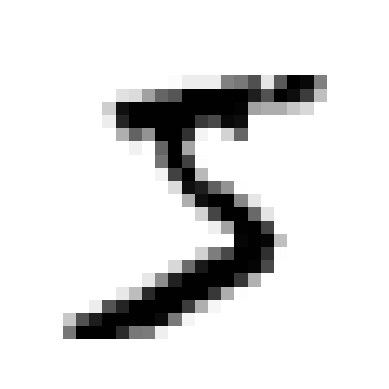

In [109]:
show_image(X[0])

In [106]:
sgd_clf.decision_function([some_digit]).round()

array([[-32928.,  -8835.,  -9117.,   8110., -20825.,  -7277., -23298.,
        -21227.,  -3488.,  -5439.]])

In [107]:
sgd_clf.decision_function([X[0]]).round()

array([[-31893., -19048.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

The classifier predicted both test images as **class 3**.

* The first image was actually **3** → **Correct prediction**
* The second image was actually **5** → **Incorrect prediction**

The `decision_function()` returns a score for each class. Most scores can be **negative**, meaning the classifier has less confidence in those classes. The predicted class has the **highest score**, even if that score is not necessarily positive.

This shows that the classifier can confuse visually similar digits, so evaluating it on multiple samples is necessary.

Since the MNIST classes contain roughly the same number of images, **accuracy** is a suitable metric for evaluating the multiclass classifier. The `cross_val_score()` function can be used to evaluate the model using cross-validation.


In [108]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

MNIST has **10 classes**, from `0` to `9`.

If a classifier randomly chooses one of these 10 classes with equal probability, the probability of making a correct prediction is:

$$
\frac{1}{10} = 10\%
$$

Therefore, a random classifier is expected to achieve about **10% accuracy** on MNIST.


# Feature Scaling

`StandardScaler` is used to standardize the features so that each feature has approximately:

$$
\text{mean}=0,\qquad \text{standard deviation}=1
$$

In MNIST, each pixel is considered a **feature**.

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

* `astype("float64")` converts the pixel values to floating-point numbers.
* `fit` calculates the mean and standard deviation of each feature from the training data.
* `transform` standardizes the features using those values.

The standardization formula is:

$$
x_{\text{scaled}} = \frac{x-\mu}{\sigma}
$$

After scaling, the same `SGDClassifier` is evaluated again using cross-validation. Scaling the input features improves the classifier's accuracy from about **86.85% to 89.65%** in this experiment.

The model itself has not changed; only the scale of its input features has been changed.

In [113]:
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

# Error Analysis

After finding a promising model, we can analyze the types of errors it makes to understand where the model performs well and where it struggles.

To analyze the errors, we first generate **out-of-sample predictions** using `cross_val_predict()` and then use these predictions to build a **Confusion Matrix**.


In [118]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\m\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


The Confusion Matrix shows how the classifier's predictions are distributed across the actual classes.

Most values on the **main diagonal** indicate that most images were classified correctly, because the actual class matches the predicted class.

However, raw counts can be misleading when different classes contain different numbers of images. A darker or larger cell does not necessarily mean that the classifier performs worse on that class; it may simply contain more samples.

To make the comparison more meaningful, we can **normalize the Confusion Matrix by the true class**. Each value is divided by the **sum of its row**, so the values represent the proportion of images in each actual class that were assigned to each predicted class.

Setting `normalize="true"` performs this row-wise normalization, while `values_format=".0%"` displays the normalized values as percentages without decimal places.

The normalized matrix makes it easier to compare the classifier's performance across different classes, regardless of how many samples each class contains.


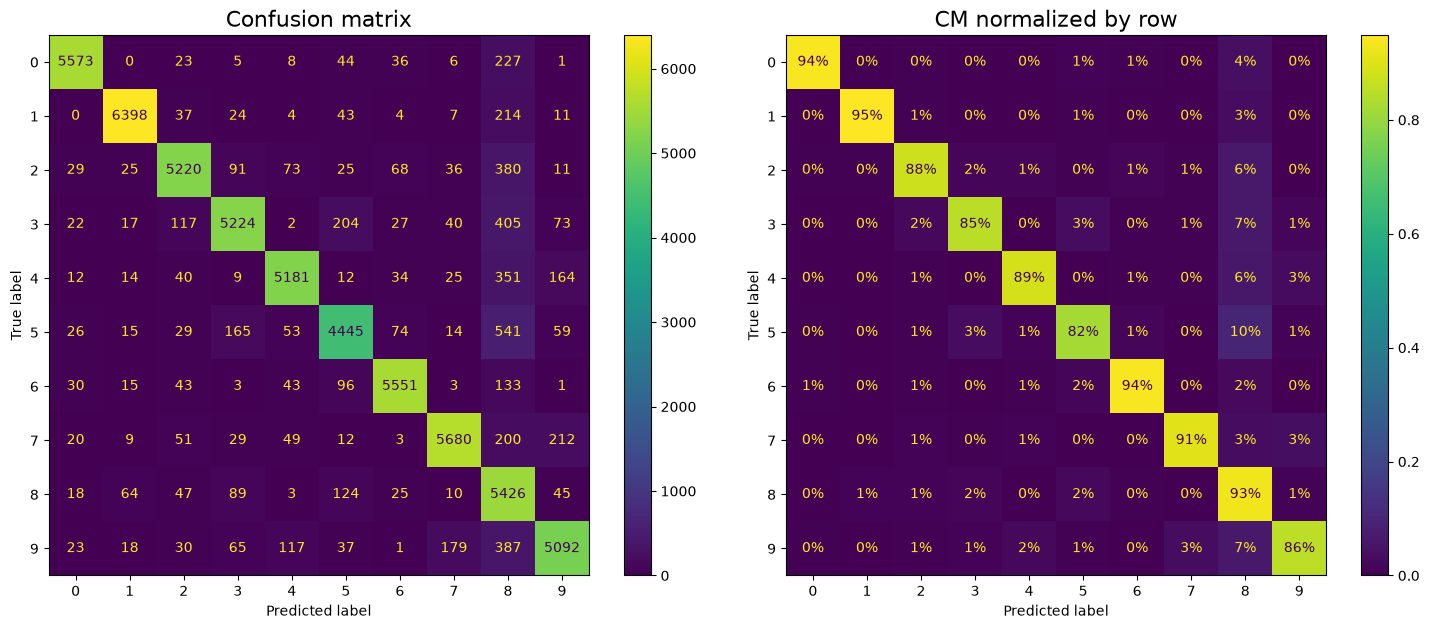

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    ax=axes[0]
)

axes[0].set_title("Confusion matrix", fontsize=16)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    normalize="true",
    values_format=".0%",
    ax=axes[1]
)

axes[1].set_title("CM normalized by row", fontsize=16)

plt.tight_layout()
plt.show()

The normalized Confusion Matrix can reveal which classes are commonly confused with each other.

For example, if many actual `5`s are classified as `8`, but only a small percentage of actual `8`s are classified as `5`, the confusion is **not symmetrical**.

To make these error patterns easier to see, we can set the weight of **correct predictions to zero**. This removes the dominant correct predictions from the visualization and makes the misclassifications stand out more clearly.


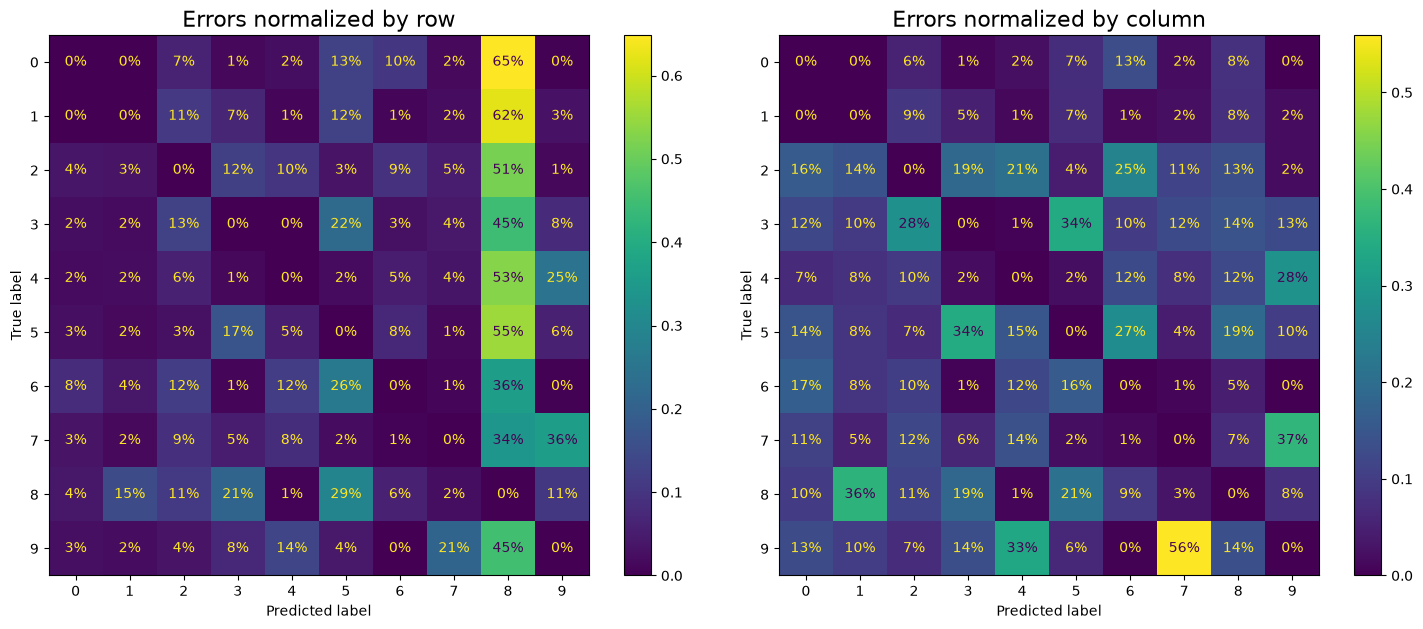

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
 sample_weight=sample_weight,
 normalize="true", values_format=".0%",
 ax=axes[0])

axes[0].set_title("Errors normalized by row", fontsize=16)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
 sample_weight=sample_weight,
 normalize="pred", values_format=".0%",
 ax=axes[1])

axes[1].set_title("Errors normalized by column", fontsize=16)

plt.tight_layout()
plt.show()

When correct predictions are given zero weight, the percentages represent the **distribution of errors**, not the proportion of all samples.

For example, if a cell shows `36%` for actual `7` and predicted `9`, it means that **36% of the errors made on images of 7s** were misclassifications as 9s.

It does **not** mean that 36% of all images of 7s were classified as 9s. The actual percentage of all 7s misclassified as 9s can be much smaller.

This interpretation applies specifically to the **error-only Confusion Matrix**, where correct predictions are given zero weight.

# Row and Column Normalization

With **row normalization**, each value is divided by the sum of its row. This answers:

> Among the samples that actually belong to this class, how are they distributed among the predicted classes?

With **column normalization**, each value is divided by the sum of its column. This answers:

> Among the samples predicted as this class, what are their actual classes?

Therefore:

* **Row normalization** → focuses on the **actual class**.
* **Column normalization** → focuses on the **predicted class**.

For an error-only matrix, the same idea applies, but the percentages describe the **distribution of errors** rather than all predictions.

# Improving the Classifier

Analyzing the Confusion Matrix can reveal which types of errors should be reduced and suggest ways to improve the classifier.

For example, if the classifier produces many **false 8s**, we can try to reduce these errors by:

* Collecting more training examples of digits that look like `8` but are not `8`.
* **Engineering new features** that help distinguish similar digits, such as the number of closed loops.
* **Preprocessing the images** to make useful patterns, such as closed loops, more prominent.

The main goal of Error Analysis is to use the model's errors to identify opportunities for improving the classifier.


# Analyzing Individual Errors

Analyzing individual misclassified examples can provide deeper insight into **what the classifier is doing and why it fails**.

For example, we can visualize examples of `3`s and `5`s in a Confusion Matrix-style layout to inspect the patterns behind their misclassifications.

Examining the actual images can help us understand which visual patterns cause the classifier to confuse similar classes and can suggest ways to improve the model.


In [141]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

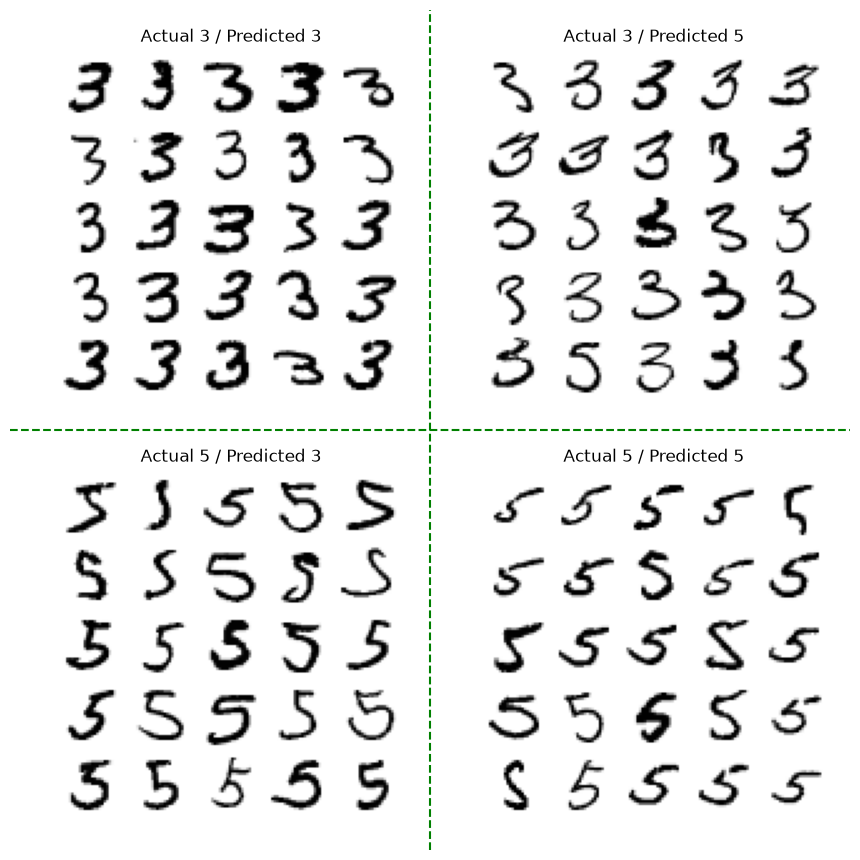

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

groups = [
    (X_aa, "Actual 3 / Predicted 3"),
    (X_ab, "Actual 3 / Predicted 5"),
    (X_ba, "Actual 5 / Predicted 3"),
    (X_bb, "Actual 5 / Predicted 5")
]

for ax, (images, title) in zip(axes.ravel(), groups):
    images = images[:25]

    grid = images.reshape(5, 5, 28, 28)
    combined = grid.transpose(0, 2, 1, 3).reshape(140, 140)

    ax.imshow(combined, cmap="binary")
    ax.set_title(title)
    ax.axis("off")

fig.lines.append(
    plt.Line2D(
        [0.5, 0.5], [0.08, 0.92],
        transform=fig.transFigure,
        linestyle="--",
        c="green"
    )
)

fig.lines.append(
    plt.Line2D(
        [0.08, 0.92], [0.5, 0.5],
        transform=fig.transFigure,
        linestyle="--",
        c="green"
    )
)

plt.show()

Some images may be genuinely difficult to classify, even for humans. However, other errors may look obvious to us.

This highlights an important point: **what looks obvious to humans may not be obvious to the model**, because human vision performs

 complex pattern recognition and preprocessing automatically.


# Why the Linear Classifier Makes Errors

`SGDClassifier` is a **linear model**. It assigns a weight to each pixel and calculates a score by taking a weighted sum of the pixel intensities.

Conceptually:

$$
score = w_1x_1 + w_2x_2 + \dots + w_{784}x_{784} + b
$$

Because digits such as `3` and `5` can differ in only a few pixels, a linear model may easily confuse them.

The classifier is also sensitive to **small shifts and rotations** of the images. A slight change in the position of important pixels can significantly affect the resulting score.

This shows that a task that looks simple to humans may still be difficult for a simple model.

# Reducing 3/5 Confusion

The main difference between some `3`s and `5`s can be the position of a small connecting line. A slight shift can therefore cause the classifier to confuse the two classes.

One possible solution is to **preprocess the images** so that they are well-centered and correctly oriented.

However, this can be difficult because we first need to determine the appropriate correction for each image.


# Data Augmentation

A simpler approach is **Data Augmentation**: creating modified versions of existing training images, such as slightly shifted or rotated variants, and adding them to the training set.

The goal is to expose the model to common variations so that it learns to become more **tolerant to small changes** while preserving the original class.

Data augmentation does not require collecting completely new real-world data; it creates additional training examples from existing data.

The general idea is:

$$
\text{Original Training Data}
\rightarrow
\text{Modified Variants}
\rightarrow
\text{Larger Training Set}
\rightarrow
\text{More Robust Model}
$$


# Multilabel Classification

In **Multilabel Classification**, each instance can be assigned **multiple binary labels** at the same time.

For example, each MNIST digit can have two labels:

* **Large** → whether the digit is `7` or greater.
* **Odd** → whether the digit is odd.

These labels are combined into a **multilabel target matrix**, where each column represents one label.

`KNeighborsClassifier` supports multilabel classification, so it can be trained directly using multiple labels for each instance.

Each prediction can therefore contain multiple `True` or `False` values, one for each label.


In [99]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= "7")
y_train_odd = (y_train.astype("int8") % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([False, True]), array([False, True])]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [100]:
y_multilabel

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]], shape=(60000, 2))

In [101]:
knn_clf.predict([some_digit])

array([[False,  True]])

**This digit is less than 7 (False) and odd (True)**

In [102]:
knn_clf.predict([X[123]])

array([[ True,  True]])

**This digit is greater than or equal to 7 (True) and odd (True)**

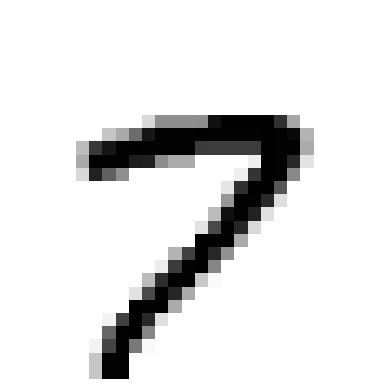

In [103]:
show_image(X[123])

In [104]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [105]:
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

A simple average of F1 scores assumes that all labels are equally important. However, labels may have different numbers of instances.

For example, if there are many more pictures of Alice than Bob or Charlie, we may want Alice's F1 score to have a greater influence on the overall score.

**Support** is the number of instances that actually belong to a particular label.

With `average="weighted"`, each label's F1 score is weighted according to its support.

Conceptually:

$$
F1_{weighted} =
\frac{
support_1F1_1 + support_2F1_2 + \dots
}{
support_1 + support_2 + \dots
}
$$

Therefore:

* **Macro average** → all labels have equal weight.
* **Weighted average** → labels with more instances have greater weight.

The weight is based on the number of instances, not on the intrinsic importance of the label.


# Classifier Chains

When a classifier does not natively support multilabel classification, such as `SVC`, we can train one binary classifier for each label.

A **Classifier Chain** organizes these classifiers sequentially so that each classifier receives the original input features plus the predictions of the classifiers that came before it.

This can help the models take **dependencies between labels** into account.

Scikit-Learn provides the `ClassifierChain` class to implement this approach.

By default, the models later in the chain are trained using the **true labels** of the previous classifiers.

By setting the `cv` parameter, Scikit-Learn generates **out-of-sample predictions** for the previous classifiers using cross-validation and uses these predictions to train the models later in the chain. This makes the training process more similar to what happens during prediction.

The **order of the classifiers in the chain can affect the final performance**, because each classifier can only use predictions from classifiers that come before it.

If the labels are independent, using a classifier chain may provide little or no benefit.


In [106]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])


,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,SVC()
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.",3
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
Name,Type,Value
chain_method_ chain_method_: strPrediction method used by estimators in the chain for the predictionfeatures.,str,'predict'
classes_ classes_: listA list of arrays of length ``len(estimators_)`` containing theclass labels for each estimator in the chain.,list,"[array([False, True]), array([False, True])]"
estimators_ estimators_: listA list of clones of base_estimator.,list,"[SVC(), SVC()]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `base_estimator` exposes such an attribute when fit... versionadded:: 0.24,int,784


In [107]:
chain_clf.predict([some_digit])

array([[0., 1.]])

**This digit is less than 7 (False) and odd (True)**